# Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

VITAL_COLS = ['HeartRate','BloodPressureSystolic','BloodPressureDiastolic',
              'BloodOxygenLevel','BodyTemperature','RespiratoryRate',
              'SleepHours','StressLevel']

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 222.6 kB/s eta 0:00:43
   ---------------------------------------- 0.0/9.6 MB 262.6 kB/s eta 0:00:37
   ---------------------------------------- 0.0/9.6 MB 262.6 kB/s eta 0:00:37
   ---------------------------------------- 0.1/9.6 MB 273.8 kB/s eta 0:00:35
   ---------------------------------------- 0.1/9.6 MB 375.8 kB/s eta 0:00:26
   ---------------------------------------- 0.1/9.6 MB 375.8 kB/s eta 0:00:26
    --------------------------------------- 0.2/9.6 MB 459.5 kB/s eta 0:00:21
    --------------------------------------- 0.2/9.6 MB 464.2 kB/s eta 0:00:21
    --------------------------------------- 0.2/9.6 MB 551.4 kB/s eta 0:00:17
   - -------------------------------------- 0.3/9.6 MB 700.2 kB/s eta 0:00:14
   - -------------------------------------- 0.4/9.6 MB 765.8 kB/s eta 0:00:13
   -


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\USR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
df = pd.read_csv('patient_vitals.csv', parse_dates=['Timestamp'])

RANGES = {
    'HeartRate':(40,180),'BloodPressureSystolic':(80,200),
    'BloodPressureDiastolic':(50,130),'BloodOxygenLevel':(85,100),
    'BodyTemperature':(35.5,41.0),'RespiratoryRate':(10,40),
    'SleepHours':(2,12),'StressLevel':(1,10)
}
mask = pd.Series(True, index=df.index)
for col,(lo,hi) in RANGES.items():
    mask &= df[col].between(lo,hi,inclusive='both')
df = df[mask].copy()
df = df.sort_values(['PatientID','Timestamp']).reset_index(drop=True)
grouped = df.groupby('PatientID')
print(f"Clean rows: {len(df):,} | Patients: {df['PatientID'].nunique()}")

Clean rows: 59,212 | Patients: 500


In [21]:
def make_features(grp):
    row = {}
    for c in VITAL_COLS:
        s = grp[c]; x = np.arange(len(s))
        row[f'{c}_mean']=s.mean(); row[f'{c}_std']=s.std()
        row[f'{c}_min']=s.min();   row[f'{c}_max']=s.max()
        row[f'{c}_slope']=stats.linregress(x,s).slope if len(s)>1 else 0.0
    row['Age']=grp['Age'].iloc[0]
    row['Gender']=grp['Gender'].iloc[0]
    row['Diagnosis']=grp['Diagnosis'].iloc[0]
    return pd.Series(row)

feat_df = grouped.apply(make_features).reset_index(drop=True)
print(f"Feature matrix: {feat_df.shape}")

Feature matrix: (500, 43)


### Part A
### Cell A1

A1 — Descriptive Statistics: HeartRate

Patient: P0002 | Class: Healthy
  Mean : 72.98 bpm
  Std  : 7.64 bpm
  Min  : 56.50 bpm
  Max  : 95.70 bpm
  CV   : 10.47%

Patient: P0001 | Class: Hypertension
  Mean : 81.22 bpm
  Std  : 9.94 bpm
  Min  : 57.20 bpm
  Max  : 106.20 bpm
  CV   : 12.24%

Patient: P0008 | Class: Arrhythmia
  Mean : 91.41 bpm
  Std  : 22.98 bpm
  Min  : 44.60 bpm
  Max  : 154.70 bpm
  CV   : 25.14%


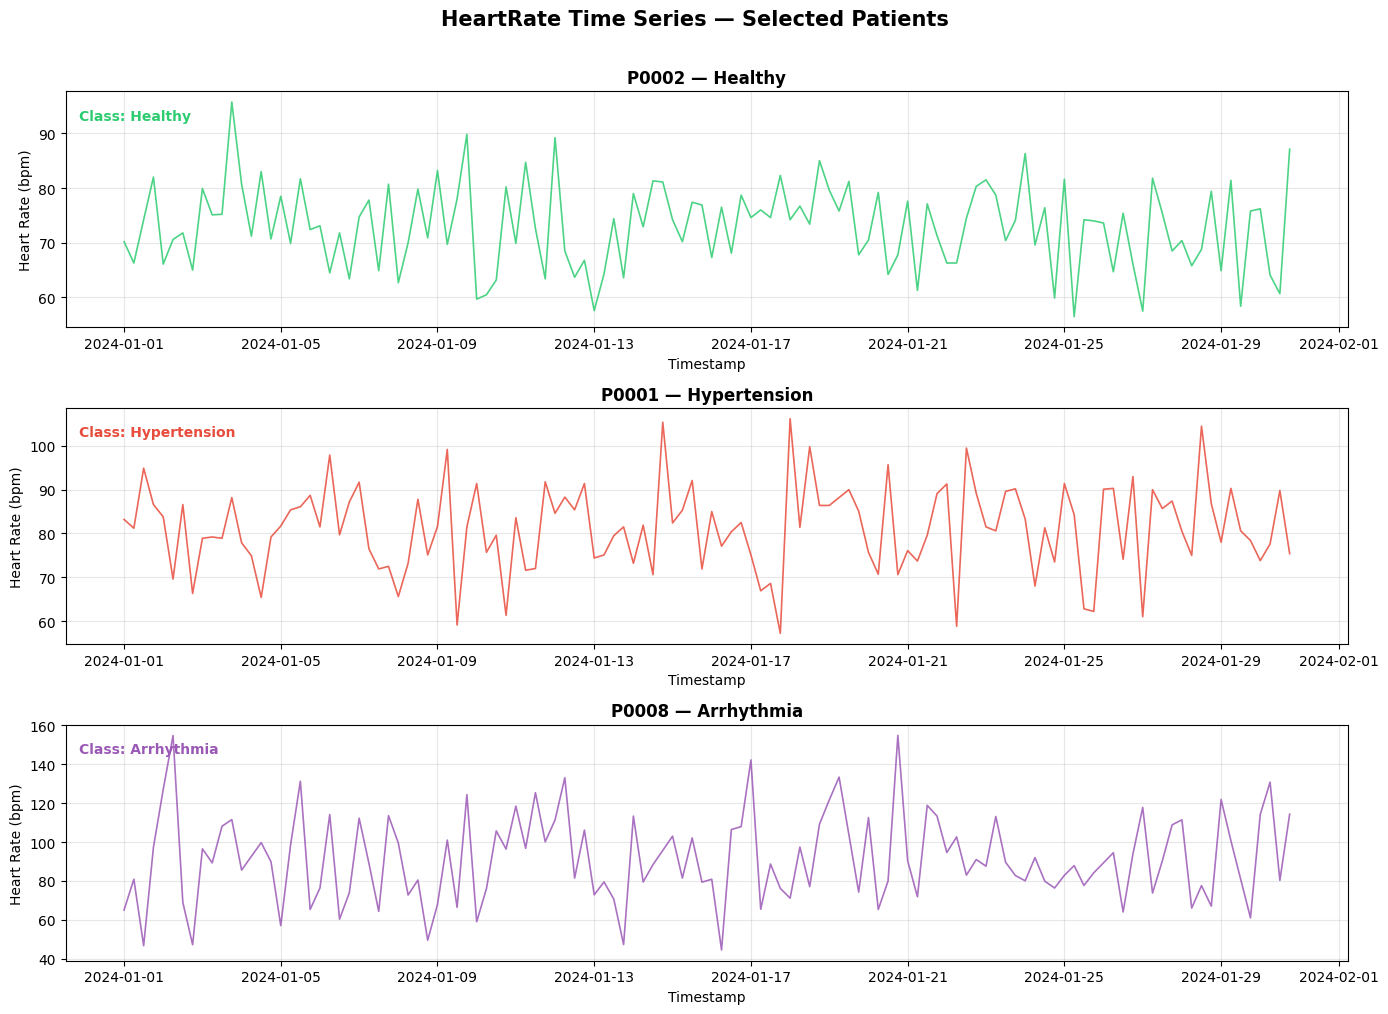


Plot saved: A1_heartrate_timeseries.png


In [22]:
# Select 3 patients
healthy_pt  = df[df['Diagnosis']=='Healthy']['PatientID'].iloc[0]
hyper_pt    = df[df['Diagnosis']=='Hypertension']['PatientID'].iloc[0]
arrhyth_pt  = df[df['Diagnosis']=='Arrhythmia']['PatientID'].iloc[0]
selected    = [healthy_pt, hyper_pt, arrhyth_pt]
labels      = ['Healthy', 'Hypertension', 'Arrhythmia']
colors      = ['#2ecc71', '#e74c3c', '#9b59b6']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle('HeartRate Time Series — Selected Patients', fontsize=15, fontweight='bold', y=1.01)

print("="*65)
print("A1 — Descriptive Statistics: HeartRate")
print("="*65)
for ax, pid, label, color in zip(axes, selected, labels, colors):
    grp = df[df['PatientID']==pid].sort_values('Timestamp')
    hr  = grp['HeartRate']
    ax.plot(grp['Timestamp'], hr, color=color, linewidth=1.2, alpha=0.85)
    ax.set_title(f'{pid} — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Heart Rate (bpm)')
    ax.grid(True, alpha=0.3)
    ax.annotate(f'Class: {label}', xy=(0.01,0.88), xycoords='axes fraction',
                fontsize=10, color=color, fontweight='bold')
    mean_val = hr.mean(); std_val = hr.std()
    cv = std_val/mean_val*100
    print(f"\nPatient: {pid} | Class: {label}")
    print(f"  Mean : {mean_val:.2f} bpm")
    print(f"  Std  : {std_val:.2f} bpm")
    print(f"  Min  : {hr.min():.2f} bpm")
    print(f"  Max  : {hr.max():.2f} bpm")
    print(f"  CV   : {cv:.2f}%")

plt.tight_layout()
plt.savefig('A1_heartrate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: A1_heartrate_timeseries.png")

### A2-- Rolling Average & Decomposition

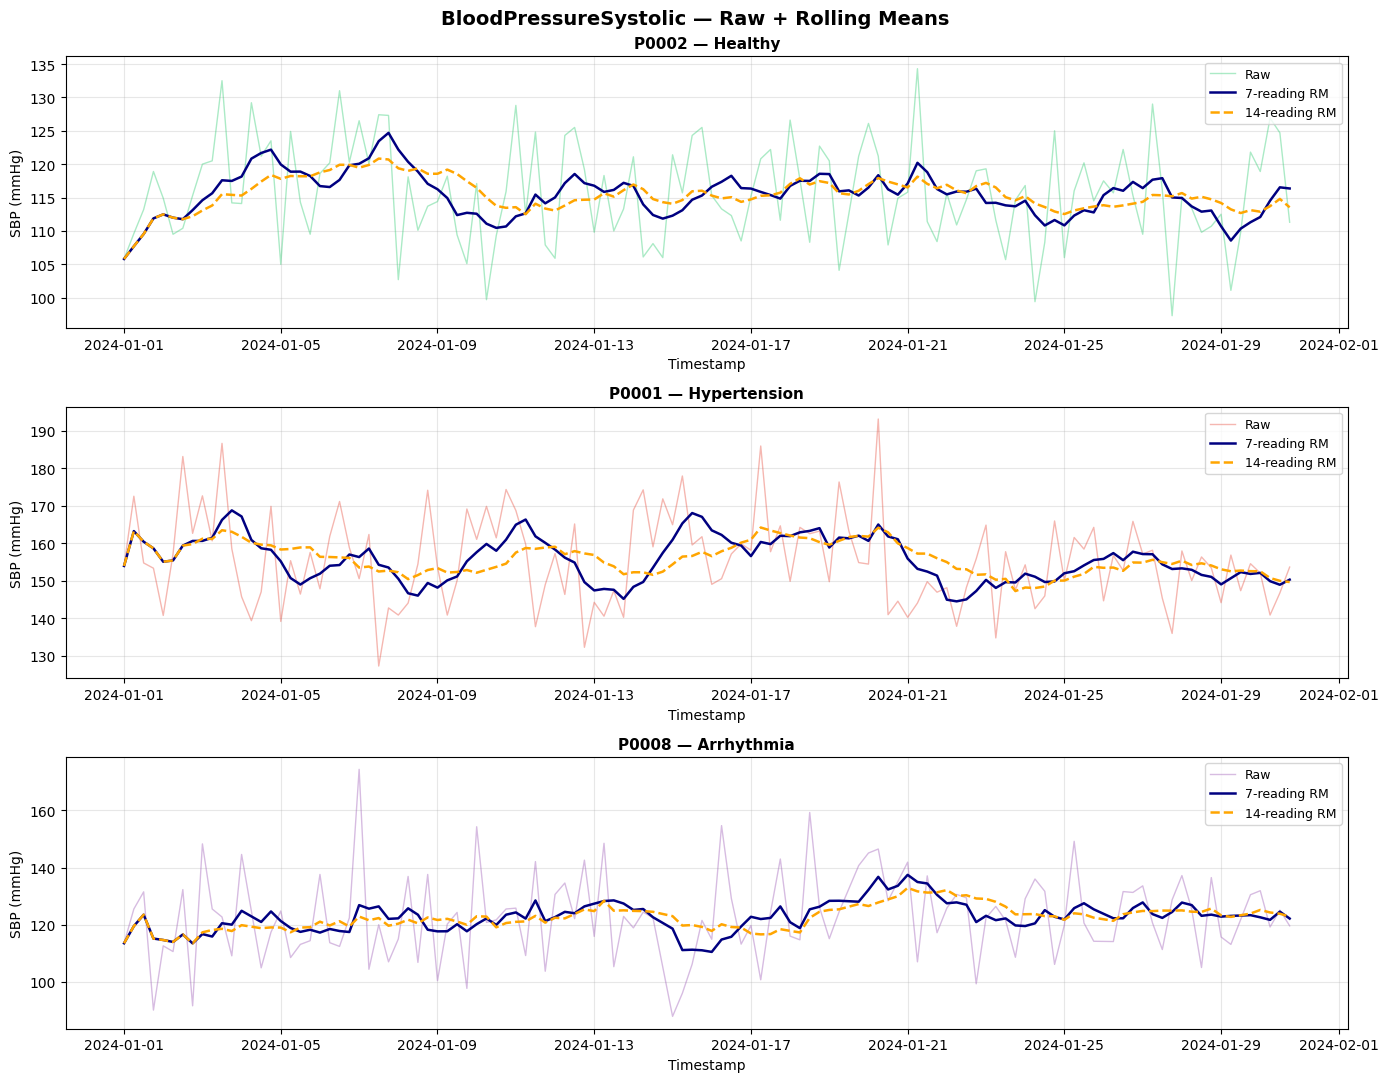

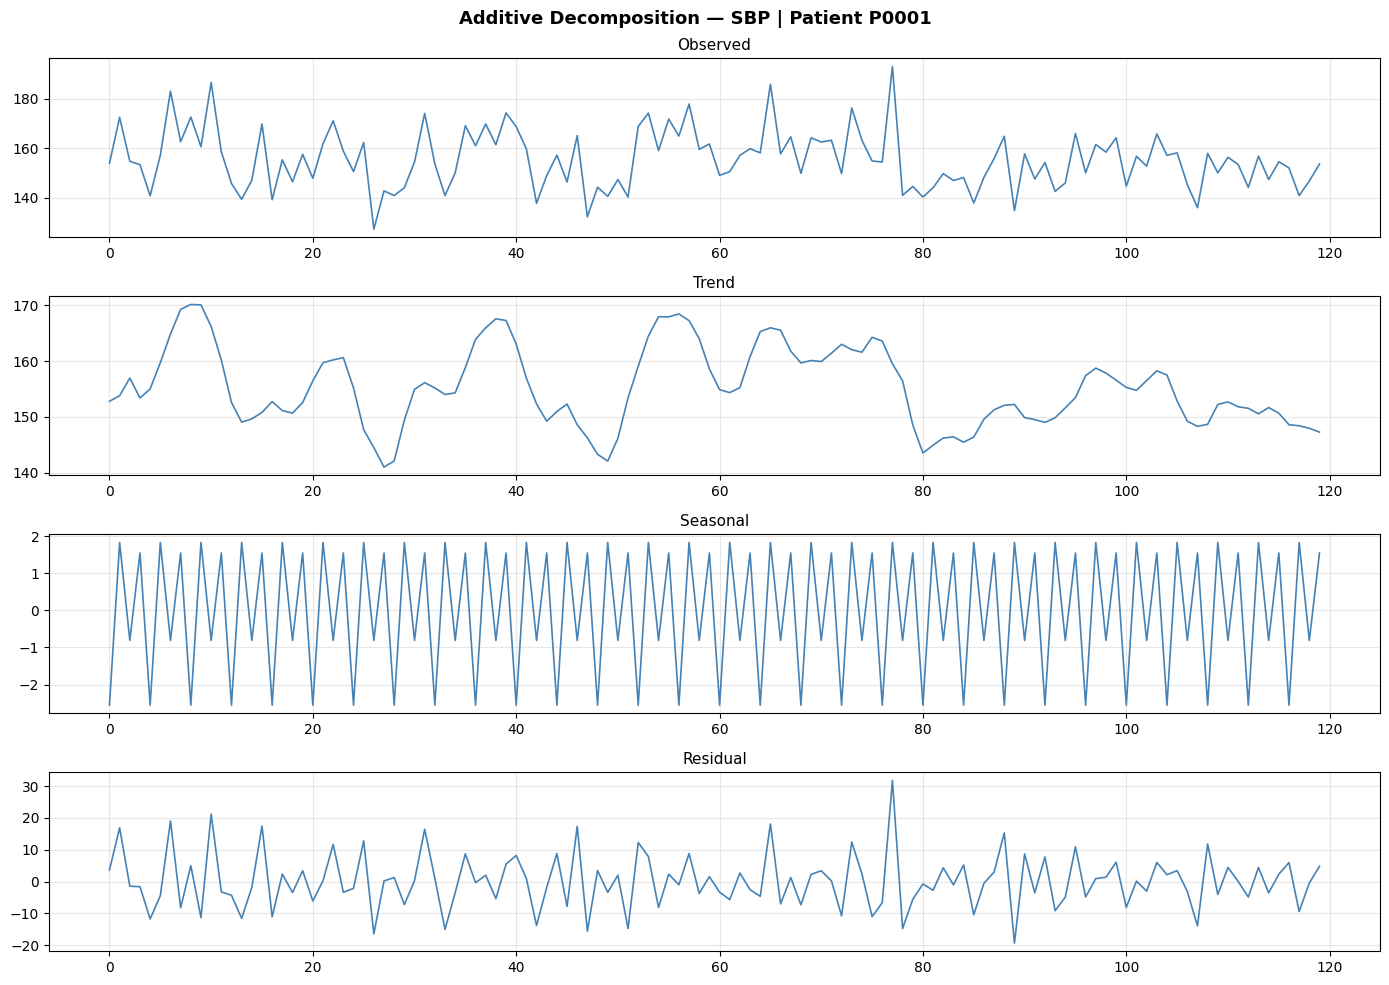

Longest patient: P0001 (120 readings)
Trend slope    : -0.0475 mmHg/reading
Trend direction: downward
Trend range    : 140.96 – 170.16 mmHg
Magnitude      : 29.20 mmHg


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('BloodPressureSystolic — Raw + Rolling Means', fontsize=14, fontweight='bold')

for ax, pid, label, color in zip(axes, selected, labels, colors):
    grp = df[df['PatientID']==pid].sort_values('Timestamp').reset_index(drop=True)
    bp  = grp['BloodPressureSystolic']
    rm7  = bp.rolling(7,  min_periods=1).mean()
    rm14 = bp.rolling(14, min_periods=1).mean()
    ax.plot(grp['Timestamp'], bp,   color=color,    alpha=0.4, linewidth=1,   label='Raw')
    ax.plot(grp['Timestamp'], rm7,  color='navy',   linewidth=1.8, label='7-reading RM')
    ax.plot(grp['Timestamp'], rm14, color='orange', linewidth=1.8, linestyle='--', label='14-reading RM')
    ax.set_title(f'{pid} — {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('SBP (mmHg)')
    ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('A2_rolling_means.png', dpi=150, bbox_inches='tight')
plt.show()

# Decomposition — longest patient sequence
longest_pid = df.groupby('PatientID').size().idxmax()
grp_long = df[df['PatientID']==longest_pid].sort_values('Timestamp').reset_index(drop=True)
bp_series = grp_long['BloodPressureSystolic']
bp_series.index = pd.RangeIndex(len(bp_series))

decomp = seasonal_decompose(bp_series, model='additive', period=4, extrapolate_trend='freq')

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 10))
fig2.suptitle(f'Additive Decomposition — SBP | Patient {longest_pid}', fontsize=13, fontweight='bold')
for ax, data, title in zip(axes2,
    [bp_series, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed','Trend','Seasonal','Residual']):
    ax.plot(data, color='steelblue', linewidth=1.2)
    ax.set_title(title, fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('A2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

trend_clean = decomp.trend.dropna()
trend_slope = np.polyfit(np.arange(len(trend_clean)), trend_clean, 1)[0]
direction   = 'upward' if trend_slope > 0.01 else ('downward' if trend_slope < -0.01 else 'stable')
print(f"Longest patient: {longest_pid} ({len(bp_series)} readings)")
print(f"Trend slope    : {trend_slope:.4f} mmHg/reading")
print(f"Trend direction: {direction}")
print(f"Trend range    : {trend_clean.min():.2f} – {trend_clean.max():.2f} mmHg")
print(f"Magnitude      : {trend_clean.max()-trend_clean.min():.2f} mmHg")

### Anomaly Detection

A3 — Anomaly Detection (μ ± 2σ on HeartRate)
Total anomalous readings : 2629 / 59212 (4.44%)

Anomaly % by Diagnosis class:
     Diagnosis  total  anomalies      pct
    Arrhythmia   9260        379 4.092873
      Diabetes  11015        494 4.484793
       Healthy  19551        887 4.536852
  Hypertension  14748        653 4.427719
Sleep Disorder   4638        216 4.657180

Top 5 patients by anomaly count:
PatientID    Diagnosis  anomaly_count
    P0017 Hypertension              9
    P0029     Diabetes              9
    P0095   Arrhythmia              9
    P0427      Healthy              9
    P0402      Healthy              9


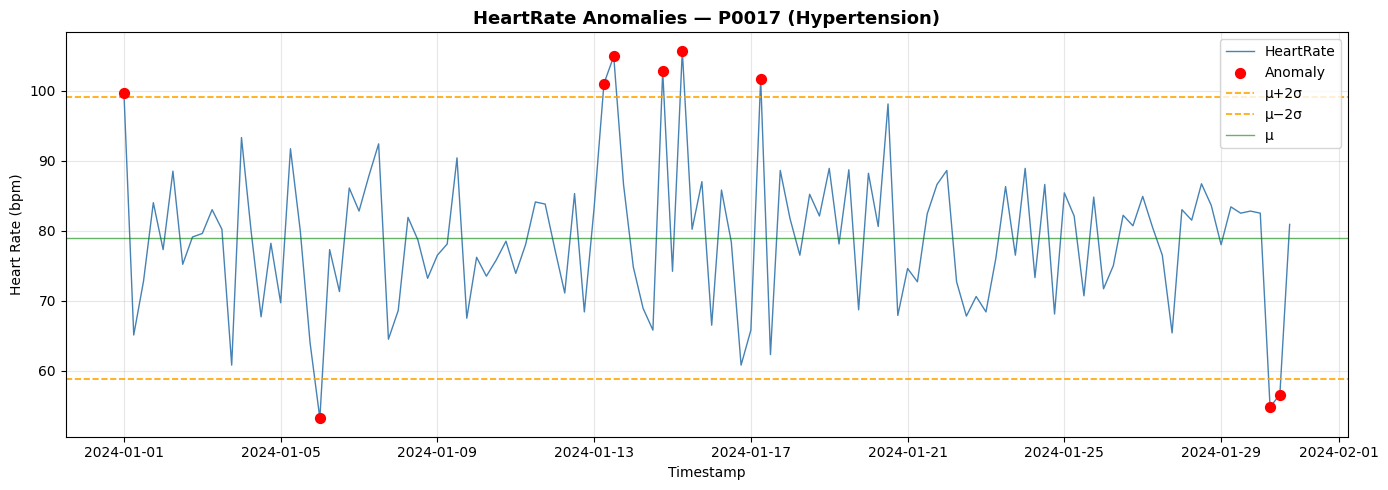


Arrhythmia anomaly rate : 4.09%
Healthy anomaly rate    : 4.54%
Ratio                   : 0.90x higher in Arrhythmia


In [24]:
# Compute per-patient anomalies
anomaly_records = []
for pid, grp in grouped:
    grp = grp.sort_values('Timestamp').copy()
    mu, sigma = grp['HeartRate'].mean(), grp['HeartRate'].std()
    grp['anomaly'] = (grp['HeartRate'] > mu + 2*sigma) | (grp['HeartRate'] < mu - 2*sigma)
    grp['mu'] = mu; grp['sigma'] = sigma
    anomaly_records.append(grp)

anom_df = pd.concat(anomaly_records).reset_index(drop=True)

# Dataset-wide totals
total_anom  = anom_df['anomaly'].sum()
total_reads = len(anom_df)
print("="*65)
print("A3 — Anomaly Detection (μ ± 2σ on HeartRate)")
print("="*65)
print(f"Total anomalous readings : {total_anom} / {total_reads} ({total_anom/total_reads*100:.2f}%)")

# Per-class anomaly rate
print("\nAnomaly % by Diagnosis class:")
class_anom = anom_df.groupby('Diagnosis').agg(
    total=('anomaly','count'), anomalies=('anomaly','sum')).reset_index()
class_anom['pct'] = class_anom['anomalies']/class_anom['total']*100
print(class_anom.to_string(index=False))

# Top 5 patients by anomaly count
top5_anom = (anom_df.groupby(['PatientID','Diagnosis'])['anomaly']
             .sum().reset_index()
             .rename(columns={'anomaly':'anomaly_count'})
             .sort_values('anomaly_count', ascending=False).head(5))
print("\nTop 5 patients by anomaly count:")
print(top5_anom.to_string(index=False))

# Plot anomaly-heavy patient
top_pid = top5_anom.iloc[0]['PatientID']
grp_top = anom_df[anom_df['PatientID']==top_pid].sort_values('Timestamp')
normal  = grp_top[~grp_top['anomaly']]
anomaly = grp_top[grp_top['anomaly']]
mu_top  = grp_top['mu'].iloc[0]; sig_top = grp_top['sigma'].iloc[0]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(grp_top['Timestamp'], grp_top['HeartRate'], color='steelblue', linewidth=1, label='HeartRate')
ax.scatter(anomaly['Timestamp'], anomaly['HeartRate'], color='red', zorder=5, s=50, label='Anomaly')
ax.axhline(mu_top+2*sig_top, color='orange', linestyle='--', linewidth=1.2, label='μ+2σ')
ax.axhline(mu_top-2*sig_top, color='orange', linestyle='--', linewidth=1.2, label='μ−2σ')
ax.axhline(mu_top, color='green', linestyle='-', linewidth=1, alpha=0.6, label='μ')
ax.set_title(f'HeartRate Anomalies — {top_pid} ({top5_anom.iloc[0]["Diagnosis"]})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Timestamp'); ax.set_ylabel('Heart Rate (bpm)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('A3_anomaly_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Arrhythmia vs Healthy comparison
arr_pct = class_anom[class_anom['Diagnosis']=='Arrhythmia']['pct'].values[0]
hlt_pct = class_anom[class_anom['Diagnosis']=='Healthy']['pct'].values[0]
print(f"\nArrhythmia anomaly rate : {arr_pct:.2f}%")
print(f"Healthy anomaly rate    : {hlt_pct:.2f}%")
print(f"Ratio                   : {arr_pct/hlt_pct:.2f}x higher in Arrhythmia")

### Part B Code
### Cell B1-- Distance Metrics

In [25]:
feat_df2 = feat_df.copy()
feat_df2['Gender'] = LabelEncoder().fit_transform(feat_df2['Gender'])
feature_cols = [c for c in feat_df2.columns if c != 'Diagnosis']
X_all = feat_df2[feature_cols].values
diag_all = feat_df2['Diagnosis'].values
pid_all  = feat_df.index.tolist()

scaler_b = StandardScaler()
X_scaled = scaler_b.fit_transform(X_all)

# 10 random query patients seed=42
rng = np.random.default_rng(42)
query_idx = rng.choice(len(X_scaled), size=10, replace=False)

print("="*90)
print("B1 — Top-3 Nearest Neighbours: Euclidean vs Manhattan")
print("="*90)
print(f"{'Query ID':<10} {'Metric':<12} {'NN1 (idx,class,dist)':<30} {'NN2':<30} {'NN3':<30}")
print("-"*90)

for qi in query_idx:
    for metric_name in ['Euclidean','Manhattan']:
        if metric_name == 'Euclidean':
            dists = np.linalg.norm(X_scaled - X_scaled[qi], axis=1)
        else:
            dists = np.sum(np.abs(X_scaled - X_scaled[qi]), axis=1)
        dists[qi] = np.inf
        nn = np.argsort(dists)[:3]
        nn_str = [f"idx{nn[i]}|{diag_all[nn[i]][:6]}|{dists[nn[i]]:.2f}" for i in range(3)]
        print(f"{qi:<10} {metric_name:<12} {nn_str[0]:<30} {nn_str[1]:<30} {nn_str[2]:<30}")

B1 — Top-3 Nearest Neighbours: Euclidean vs Manhattan
Query ID   Metric       NN1 (idx,class,dist)           NN2                            NN3                           
------------------------------------------------------------------------------------------
42         Euclidean    idx183|Hypert|3.01             idx420|Hypert|3.79             idx379|Hypert|4.01            
42         Manhattan    idx183|Hypert|13.27            idx38|Hypert|15.78             idx357|Hypert|16.35           
380        Euclidean    idx310|Arrhyt|4.79             idx230|Arrhyt|4.87             idx65|Arrhyt|5.09             
380        Manhattan    idx187|Arrhyt|21.98            idx65|Arrhyt|22.36             idx230|Arrhyt|23.08           
43         Euclidean    idx90|Hypert|3.04              idx143|Hypert|3.37             idx424|Hypert|3.54            
43         Manhattan    idx90|Hypert|14.13             idx143|Hypert|14.77            idx424|Hypert|15.85           
322        Euclidean    idx314|Diabe

### Cell B2
### DTW Similarity

In [27]:
# !pip install dtaidistance
# Install if needed: !pip install dtaidistance
from dtaidistance import dtw
import itertools

SEQ_LEN = 20
eligible = df.groupby('PatientID').filter(lambda x: len(x) >= SEQ_LEN)
sequences, seq_pids, seq_diags = [], [], []
for pid, grp in eligible.groupby('PatientID'):
    seq = grp.sort_values('Timestamp')['HeartRate'].values[:SEQ_LEN]
    sequences.append(seq.astype(np.double))
    seq_pids.append(pid)
    seq_diags.append(grp['Diagnosis'].iloc[0])

sequences = np.array(sequences)
n = len(sequences)
print(f"Patients with ≥20 readings: {n}")

# Pairwise DTW
dtw_matrix = np.zeros((n, n))
for i, j in itertools.combinations(range(n), 2):
    d = dtw.distance_fast(sequences[i], sequences[j])
    dtw_matrix[i,j] = dtw_matrix[j,i] = d

# 3 query patients (one per class)
dtw_queries = {}
for cls in ['Healthy','Hypertension','Arrhythmia']:
    idx = next(i for i,d in enumerate(seq_diags) if d==cls)
    dtw_queries[cls] = idx

print("\nB2 — DTW Top-3 Nearest Neighbours")
print("="*70)
for cls, qi in dtw_queries.items():
    row = dtw_matrix[qi].copy(); row[qi] = np.inf
    nn = np.argsort(row)[:3]
    print(f"\nQuery: {seq_pids[qi]} ({cls})")
    for r,ni in enumerate(nn,1):
        print(f"  Rank {r}: {seq_pids[ni]} | {seq_diags[ni]} | DTW={row[ni]:.3f}")

# Quantify within-class match rate
dtw_within = 0; euc_within = 0; total_q = 0
for qi in range(n):
    row_d = dtw_matrix[qi].copy(); row_d[qi]=np.inf
    nn_dtw = np.argsort(row_d)[:3]
    dtw_within += sum(seq_diags[ni]==seq_diags[qi] for ni in nn_dtw)

    euc_row = np.linalg.norm(X_scaled - X_scaled[qi], axis=1)
    euc_row[qi] = np.inf
    nn_euc = np.argsort(euc_row)[:3]
    euc_within += sum(diag_all[ni]==diag_all[qi] for ni in nn_euc)
    total_q += 3

print(f"\nDTW within-class match rate  : {dtw_within}/{total_q} ({100*dtw_within/total_q:.1f}%)")
print(f"Euclidean within-class rate  : {euc_within}/{total_q} ({100*euc_within/total_q:.1f}%)")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\USR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 330.3 kB/s eta 0:00:05
    --------------------------------------- 0.0/1.4 MB 262.6 kB/s eta 0:00:06
    --------------------------------------- 0.0/1.4 MB 262.6 kB/s eta 0:00:06
   - -------------------------------------- 0.1/1.4 MB 297.7 kB/s eta 0:00:05
   - -------------------------------------- 0.1/1.4 MB 326.8 kB/s eta 0:00:05
   --- ------------------------------------ 0.1/1.4 MB 385.0 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/1.4 MB 458.0 kB/s eta 0:00:03
   ----- ---------------------------------- 0.2/1.4 MB 565.6 kB/s eta 0:00:03
   ------ --------------------------------- 0.2/1.4 MB 573.4 kB/s eta 0:00:03
   ------- -------------------------------- 0.3/1.4 MB 607.9 kB/s eta 0:00:02
   ------------ --------------------------- 0.4/1.4 MB 860.2 kB/s eta 0:00:02
   -

### New Patient Clinical Matching

In [28]:
# New patient feature vector (only matching columns)
new_raw = {
    'HeartRate_mean':98, 'HeartRate_std':18,
    'BloodPressureSystolic_mean':155, 'BloodPressureSystolic_std':12,
    'BloodOxygenLevel_mean':94, 'SleepHours_mean':4.5
}
feat_names = feature_cols
new_vec = np.zeros((1, len(feat_names)))
for i, fn in enumerate(feat_names):
    if fn in new_raw:
        new_vec[0,i] = new_raw[fn]
    else:
        new_vec[0,i] = X_all[:, i].mean()  # fill missing with dataset mean

new_vec_scaled = scaler_b.transform(new_vec)
dists = np.linalg.norm(X_scaled - new_vec_scaled, axis=1)
nn5   = np.argsort(dists)[:5]

print("B3 — New Patient: Top-5 Nearest Neighbours")
print("="*55)
for r,ni in enumerate(nn5,1):
    print(f"  Rank {r}: idx {ni:3d} | {diag_all[ni]:<15} | dist={dists[ni]:.3f}")

from collections import Counter
votes = Counter(diag_all[ni] for ni in nn5)
pred  = votes.most_common(1)[0][0]
conf  = votes[pred]/5
print(f"\nPredicted Diagnosis : {pred}")
print(f"Confidence          : {conf*100:.0f}% ({votes[pred]}/5 neighbours)")
print(f"Vote breakdown      : {dict(votes)}")

B3 — New Patient: Top-5 Nearest Neighbours
  Rank 1: idx 150 | Diabetes        | dist=5.613
  Rank 2: idx  36 | Diabetes        | dist=5.706
  Rank 3: idx 231 | Diabetes        | dist=5.847
  Rank 4: idx  64 | Diabetes        | dist=5.991
  Rank 5: idx 489 | Diabetes        | dist=6.035

Predicted Diagnosis : Diabetes
Confidence          : 100% (5/5 neighbours)
Vote breakdown      : {'Diabetes': 5}


### C1-- Decision Tree

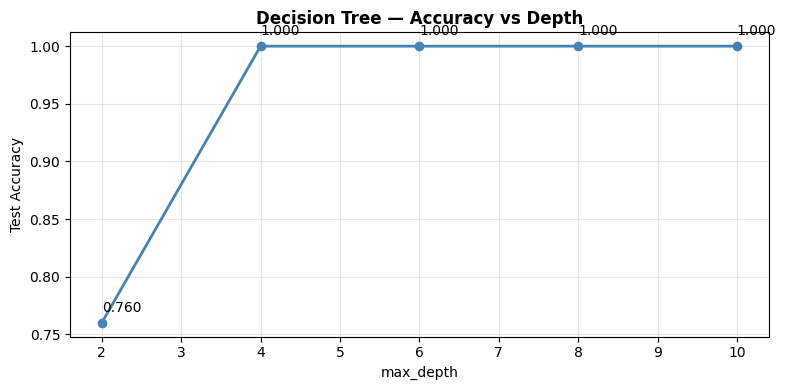

Best depth: 4 | Accuracy: 1.0000
Depth accuracies: {2: 0.76, 4: 1.0, 6: 1.0, 8: 1.0, 10: 1.0}


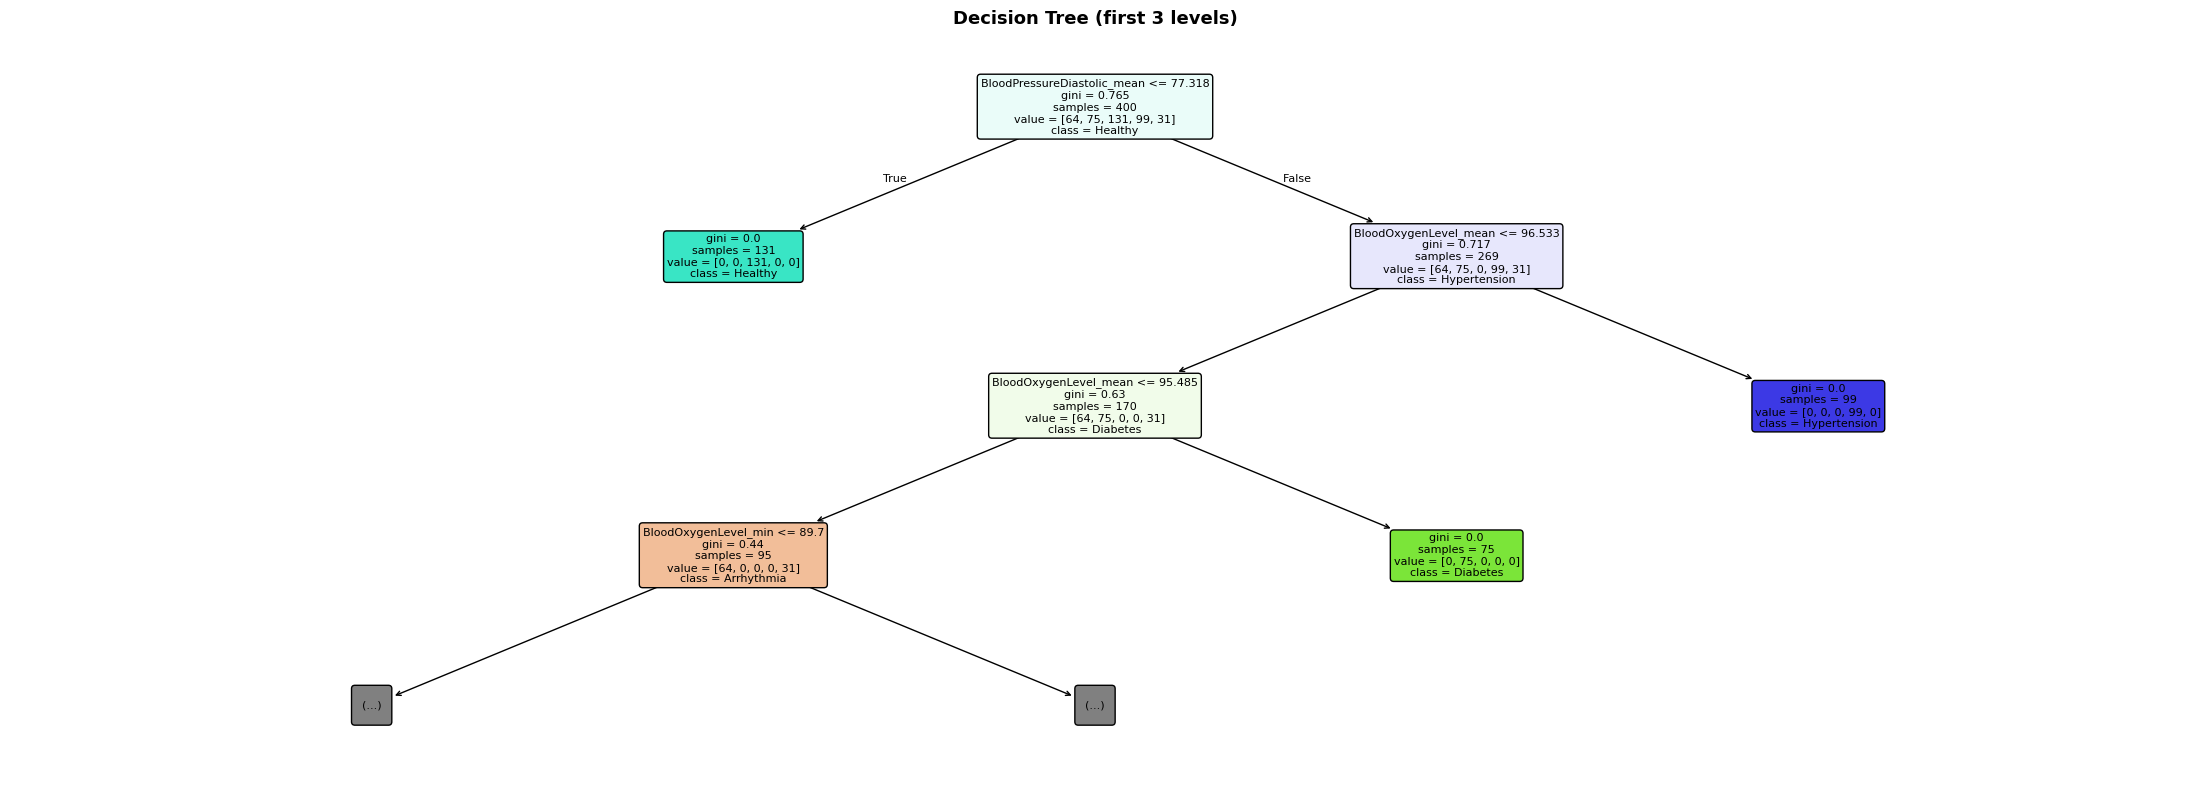


Top 5 Feature Importances:
BloodOxygenLevel_mean          0.493925
BloodPressureDiastolic_mean    0.369528
BloodOxygenLevel_min           0.136547
HeartRate_min                  0.000000
HeartRate_slope                0.000000

--- C1: Decision Tree Metrics ---
Test Accuracy : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000
                precision    recall  f1-score   support

    Arrhythmia     1.0000    1.0000    1.0000        16
      Diabetes     1.0000    1.0000    1.0000        19
       Healthy     1.0000    1.0000    1.0000        33
  Hypertension     1.0000    1.0000    1.0000        24
Sleep Disorder     1.0000    1.0000    1.0000         8

      accuracy                         1.0000       100
     macro avg     1.0000    1.0000    1.0000       100
  weighted avg     1.0000    1.0000    1.0000       100

Confusion Matrix: ['Arrhythmia', 'Diabetes', 'Healthy', 'Hypertension', 'Sleep Disorder']
[[16  0  0  0  0]
 [ 0 19  0  0  0]
 [ 0  0 3

In [29]:
feat_df3 = feat_df.copy()
feat_df3['Gender'] = LabelEncoder().fit_transform(feat_df3['Gender'])
X = feat_df3[[c for c in feat_df3.columns if c!='Diagnosis']].values
y = feat_df3['Diagnosis'].values
feat_names_c = [c for c in feat_df3.columns if c!='Diagnosis']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

# Depth tuning
depths = [2,4,6,8,10]
depth_accs = []
for d in depths:
    dt_tmp = DecisionTreeClassifier(criterion='gini',max_depth=d,random_state=42)
    dt_tmp.fit(X_train,y_train)
    depth_accs.append(dt_tmp.score(X_test,y_test))

fig,ax = plt.subplots(figsize=(8,4))
ax.plot(depths, depth_accs, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('max_depth'); ax.set_ylabel('Test Accuracy')
ax.set_title('Decision Tree — Accuracy vs Depth', fontweight='bold')
ax.grid(True,alpha=0.3)
for d,a in zip(depths,depth_accs): ax.annotate(f'{a:.3f}',(d,a),textcoords='offset points',xytext=(0,8))
plt.tight_layout()
plt.savefig('C1_depth_curve.png',dpi=150,bbox_inches='tight')
plt.show()

best_depth = depths[np.argmax(depth_accs)]
print(f"Best depth: {best_depth} | Accuracy: {max(depth_accs):.4f}")
print("Depth accuracies:", dict(zip(depths,depth_accs)))

# Train final DT
dt = DecisionTreeClassifier(criterion='gini',max_depth=best_depth,random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

# Tree visualisation (depth 3)
fig2,ax2 = plt.subplots(figsize=(22,8))
plot_tree(dt, max_depth=3, feature_names=feat_names_c,
          class_names=sorted(set(y)), filled=True, rounded=True,
          fontsize=8, ax=ax2)
ax2.set_title('Decision Tree (first 3 levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C1_tree_viz.png',dpi=150,bbox_inches='tight')
plt.show()

# Feature importances
importances = pd.Series(dt.feature_importances_, index=feat_names_c).sort_values(ascending=False)
print("\nTop 5 Feature Importances:")
print(importances.head(5).to_string())

# Metrics
print("\n--- C1: Decision Tree Metrics ---")
print(f"Test Accuracy : {accuracy_score(y_test,y_pred_dt):.4f}")
print(f"Macro Precision: {precision_score(y_test,y_pred_dt,average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test,y_pred_dt,average='macro'):.4f}")
print(f"Macro F1       : {f1_score(y_test,y_pred_dt,average='macro'):.4f}")
print(classification_report(y_test,y_pred_dt,digits=4))
print("Confusion Matrix:", sorted(set(y_test)))
print(confusion_matrix(y_test,y_pred_dt,labels=sorted(set(y_test))))

### Cell C2 — Rule-Based (extracted from DT)

In [30]:
from sklearn.tree import _tree

def extract_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    rules = []
    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            cls = class_names[np.argmax(tree_.value[node])]
            total = tree_.n_node_samples[node]
            correct = int(np.max(tree_.value[node]))
            rules.append({'conditions': list(conditions),
                          'class': cls,
                          'coverage': total,
                          'accuracy': correct/total})
        else:
            fname = feature_names[tree_.feature[node]]
            thresh = tree_.threshold[node]
            recurse(node*2+1 if False else tree_.children_left[node],
                    conditions+[f"{fname} <= {thresh:.3f}"])
            recurse(tree_.children_right[node],
                    conditions+[f"{fname} > {thresh:.3f}"])
    recurse(0, [])
    return rules

rules = extract_rules(dt, feat_names_c, sorted(set(y)))
rules_sorted = sorted(rules, key=lambda r: r['coverage'], reverse=True)

print("="*80)
print("C2 — Rule-Based Classification (extracted from Decision Tree)")
print("="*80)
shown = 0
for r in rules_sorted:
    if shown >= 10: break
    cond_str = ' AND '.join(r['conditions'][:4])
    cov_pct  = r['coverage']/len(X_train)*100
    print(f"\nRule {shown+1}:")
    print(f"  IF {cond_str}")
    print(f"  THEN Diagnosis = {r['class']}  (coverage: {cov_pct:.1f}%, accuracy: {r['accuracy']*100:.1f}%)")
    shown += 1

# Best rule per class
print("\n--- Most discriminating rule per class ---")
for cls in sorted(set(y)):
    cls_rules = [r for r in rules if r['class']==cls]
    if cls_rules:
        best_r = max(cls_rules, key=lambda r: r['accuracy']*r['coverage'])
        cond_str = ' AND '.join(best_r['conditions'][:3])
        print(f"\n  {cls}:")
        print(f"  IF {cond_str} THEN {cls}")
        print(f"  Coverage: {best_r['coverage']/len(X_train)*100:.1f}% | Accuracy: {best_r['accuracy']*100:.1f}%")

# Apply rules = same as DT predictions
print("\n--- C2: Rule-Based Metrics (same tree, applied to test) ---")
print(f"Test Accuracy  : {accuracy_score(y_test,y_pred_dt):.4f}")
print(f"Macro Precision: {precision_score(y_test,y_pred_dt,average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test,y_pred_dt,average='macro'):.4f}")
print(f"Macro F1       : {f1_score(y_test,y_pred_dt,average='macro'):.4f}")
print(classification_report(y_test,y_pred_dt,digits=4))
print(confusion_matrix(y_test,y_pred_dt,labels=sorted(set(y_test))))

C2 — Rule-Based Classification (extracted from Decision Tree)

Rule 1:
  IF BloodPressureDiastolic_mean <= 77.318
  THEN Diagnosis = Healthy  (coverage: 32.8%, accuracy: 0.8%)

Rule 2:
  IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean > 96.533
  THEN Diagnosis = Hypertension  (coverage: 24.8%, accuracy: 1.0%)

Rule 3:
  IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean <= 96.533 AND BloodOxygenLevel_mean > 95.485
  THEN Diagnosis = Diabetes  (coverage: 18.8%, accuracy: 1.3%)

Rule 4:
  IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean <= 96.533 AND BloodOxygenLevel_mean <= 95.485 AND BloodOxygenLevel_min > 89.700
  THEN Diagnosis = Arrhythmia  (coverage: 16.0%, accuracy: 1.6%)

Rule 5:
  IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean <= 96.533 AND BloodOxygenLevel_mean <= 95.485 AND BloodOxygenLevel_min <= 89.700
  THEN Diagnosis = Sleep Disorder  (coverage: 7.8%, accuracy: 3.2%)

--- Most discriminating rule per clas

### Cell C3-- KNN


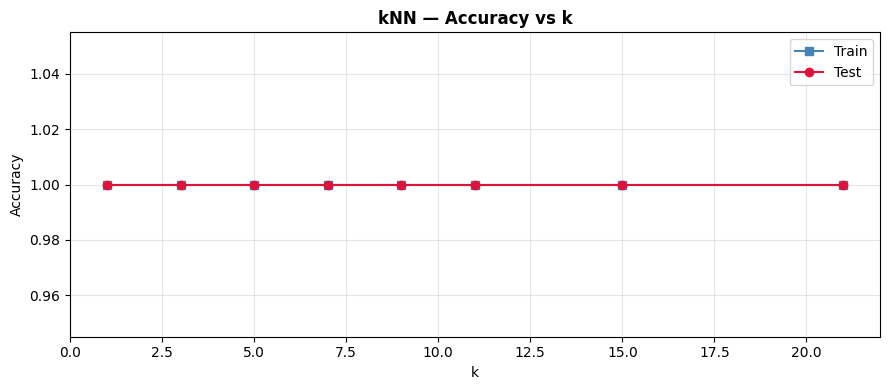

Best k: 1 | Test Acc: 1.0000
k | Train Acc | Test Acc
  k=1  : 1.0000 | 1.0000
  k=3  : 1.0000 | 1.0000
  k=5  : 1.0000 | 1.0000
  k=7  : 1.0000 | 1.0000
  k=9  : 1.0000 | 1.0000
  k=11 : 1.0000 | 1.0000
  k=15 : 1.0000 | 1.0000
  k=21 : 1.0000 | 1.0000

--- C3: kNN (euclidean) ---
Test Accuracy  : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000
                precision    recall  f1-score   support

    Arrhythmia     1.0000    1.0000    1.0000        16
      Diabetes     1.0000    1.0000    1.0000        19
       Healthy     1.0000    1.0000    1.0000        33
  Hypertension     1.0000    1.0000    1.0000        24
Sleep Disorder     1.0000    1.0000    1.0000         8

      accuracy                         1.0000       100
     macro avg     1.0000    1.0000    1.0000       100
  weighted avg     1.0000    1.0000    1.0000       100

[[16  0  0  0  0]
 [ 0 19  0  0  0]
 [ 0  0 33  0  0]
 [ 0  0  0 24  0]
 [ 0  0  0  0  8]]

--- C3: kNN (manhattan

In [33]:
scaler_c = StandardScaler()
X_train_s = scaler_c.fit_transform(X_train)
X_test_s  = scaler_c.transform(X_test)

# Encode labels for kNN to avoid sklearn dtype issue with string classes
le_knn = LabelEncoder()
y_train_enc = le_knn.fit_transform(y_train)

k_vals = [1,3,5,7,9,11,15,21]
train_accs, test_accs = [], []
for k in k_vals:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_s, y_train_enc)
    train_accs.append(knn_tmp.score(X_train_s, y_train_enc))
    test_accs.append(knn_tmp.score(X_test_s, le_knn.transform(y_test)))

fig,ax = plt.subplots(figsize=(9,4))
ax.plot(k_vals,train_accs,marker='s',label='Train',color='steelblue')
ax.plot(k_vals,test_accs, marker='o',label='Test', color='crimson')
ax.set_xlabel('k'); ax.set_ylabel('Accuracy')
ax.set_title('kNN — Accuracy vs k', fontweight='bold')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('C3_knn_curve.png',dpi=150,bbox_inches='tight')
plt.show()

best_k = k_vals[np.argmax(test_accs)]
print(f"Best k: {best_k} | Test Acc: {max(test_accs):.4f}")
print("k | Train Acc | Test Acc")
for k,tr,te in zip(k_vals,train_accs,test_accs):
    print(f"  k={k:<3}: {tr:.4f} | {te:.4f}")

# Euclidean vs Manhattan
for metric in ['euclidean','manhattan']:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_s, y_train_enc)
    y_pred_knn_enc = knn.predict(X_test_s)
    y_pred_knn = le_knn.inverse_transform(y_pred_knn_enc)
    print(f"\n--- C3: kNN ({metric}) ---")
    print(f"Test Accuracy  : {accuracy_score(y_test,y_pred_knn):.4f}")
    print(f"Macro Precision: {precision_score(y_test,y_pred_knn,average='macro'):.4f}")
    print(f"Macro Recall   : {recall_score(y_test,y_pred_knn,average='macro'):.4f}")
    print(f"Macro F1       : {f1_score(y_test,y_pred_knn,average='macro'):.4f}")
    print(classification_report(y_test,y_pred_knn,digits=4))
    print(confusion_matrix(y_test,y_pred_knn,labels=sorted(set(y_test))))

# Save best knn predictions (euclidean) for final table
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train_s, y_train_enc)
y_pred_knn_best_enc = knn_best.predict(X_test_s)
y_pred_knn_best = le_knn.inverse_transform(y_pred_knn_best_enc)

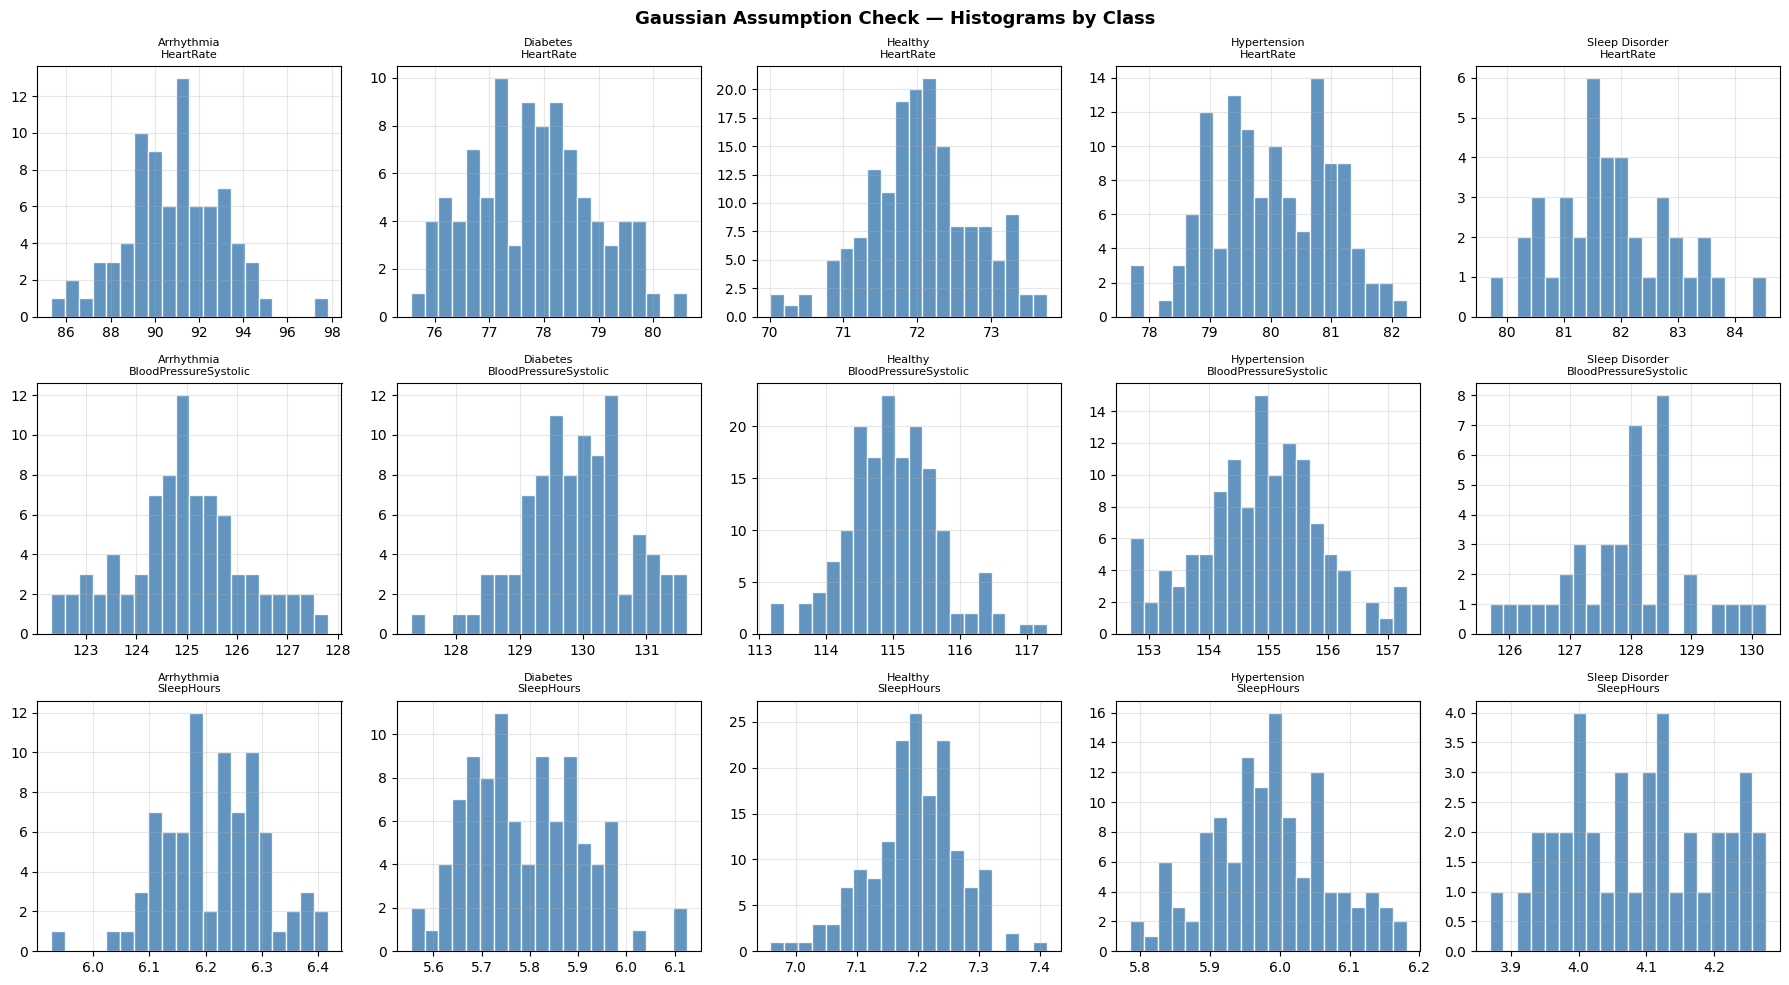

--- C4: Naïve Bayes Metrics ---
Test Accuracy  : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000
                precision    recall  f1-score   support

    Arrhythmia     1.0000    1.0000    1.0000        16
      Diabetes     1.0000    1.0000    1.0000        19
       Healthy     1.0000    1.0000    1.0000        33
  Hypertension     1.0000    1.0000    1.0000        24
Sleep Disorder     1.0000    1.0000    1.0000         8

      accuracy                         1.0000       100
     macro avg     1.0000    1.0000    1.0000       100
  weighted avg     1.0000    1.0000    1.0000       100

[[16  0  0  0  0]
 [ 0 19  0  0  0]
 [ 0  0 33  0  0]
 [ 0  0  0 24  0]
 [ 0  0  0  0  8]]

Top 5 most correlated feature pairs:
BloodPressureSystolic_mean  BloodPressureDiastolic_mean    0.992405
BloodOxygenLevel_mean       BloodOxygenLevel_min           0.985599
BloodOxygenLevel_std        BloodOxygenLevel_min           0.983052
BloodOxygenLevel_mean       Bloo

In [34]:
# Gaussian assumption check — histograms
check_features = ['HeartRate_mean','BloodPressureSystolic_mean','SleepHours_mean']
fig, axes = plt.subplots(3, 5, figsize=(18,10))
classes = sorted(feat_df['Diagnosis'].unique())
for row, feat in enumerate(check_features):
    for col, cls in enumerate(classes):
        vals = feat_df[feat_df['Diagnosis']==cls][feat]
        axes[row,col].hist(vals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
        axes[row,col].set_title(f'{cls}\n{feat.split("_")[0]}', fontsize=8)
        axes[row,col].grid(True,alpha=0.3)
plt.suptitle('Gaussian Assumption Check — Histograms by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C4_gaussian_check.png',dpi=150,bbox_inches='tight')
plt.show()

nb = GaussianNB()
nb.fit(X_train,y_train)
y_pred_nb = nb.predict(X_test)

print("--- C4: Naïve Bayes Metrics ---")
print(f"Test Accuracy  : {accuracy_score(y_test,y_pred_nb):.4f}")
print(f"Macro Precision: {precision_score(y_test,y_pred_nb,average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test,y_pred_nb,average='macro'):.4f}")
print(f"Macro F1       : {f1_score(y_test,y_pred_nb,average='macro'):.4f}")
print(classification_report(y_test,y_pred_nb,digits=4))
print(confusion_matrix(y_test,y_pred_nb,labels=sorted(set(y_test))))

# Correlation matrix
feat_df4 = feat_df.copy()
feat_df4['Gender'] = LabelEncoder().fit_transform(feat_df4['Gender'])
numeric_feats = [c for c in feat_df4.columns if c!='Diagnosis']
corr = feat_df4[numeric_feats].corr()
corr_pairs = (corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
              .stack().abs().sort_values(ascending=False))
print("\nTop 5 most correlated feature pairs:")
print(corr_pairs.head(5).to_string())

### SVM

--- C5: SVM Kernel & C Tuning (5-fold CV) ---
  kernel=rbf, C=0.1   : CV=0.9950
  kernel=rbf, C=1     : CV=1.0000
  kernel=rbf, C=10    : CV=1.0000
  kernel=rbf, C=100   : CV=1.0000
  --> Best C for rbf: 1 (CV=1.0000)

  kernel=poly, C=0.1   : CV=0.9700
  kernel=poly, C=1     : CV=1.0000
  kernel=poly, C=10    : CV=1.0000
  kernel=poly, C=100   : CV=1.0000
  --> Best C for poly: 1 (CV=1.0000)

Selected kernel: rbf, C=1

--- C5: SVM Final Metrics ---
Test Accuracy  : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000
                precision    recall  f1-score   support

    Arrhythmia     1.0000    1.0000    1.0000        16
      Diabetes     1.0000    1.0000    1.0000        19
       Healthy     1.0000    1.0000    1.0000        33
  Hypertension     1.0000    1.0000    1.0000        24
Sleep Disorder     1.0000    1.0000    1.0000         8

      accuracy                         1.0000       100
     macro avg     1.0000    1.0000    1.0000       100


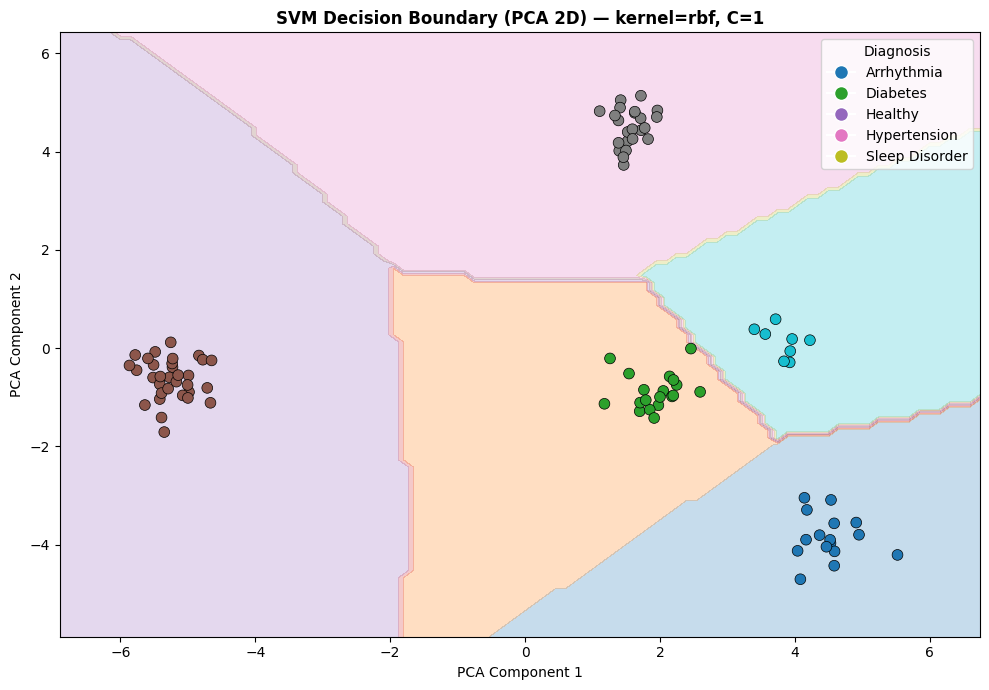

In [35]:
kernels = {'rbf': {'C_vals':[0.1,1,10,100]}, 'poly': {'C_vals':[0.1,1,10,100]}}
best_configs = {}

print("--- C5: SVM Kernel & C Tuning (5-fold CV) ---")
for kernel in ['rbf','poly']:
    best_c, best_cv = None, 0
    for C in [0.1,1,10,100]:
        kwargs = dict(kernel=kernel, C=C, random_state=42, decision_function_shape='ovr')
        if kernel=='poly': kwargs['degree']=3
        svm_tmp = SVC(**kwargs)
        cv_score = cross_val_score(svm_tmp,X_train_s,y_train,cv=5,scoring='accuracy').mean()
        print(f"  kernel={kernel}, C={C:<6}: CV={cv_score:.4f}")
        if cv_score > best_cv:
            best_cv, best_c = cv_score, C
    best_configs[kernel] = (best_c, best_cv)
    print(f"  --> Best C for {kernel}: {best_c} (CV={best_cv:.4f})\n")

# Best kernel = rbf (typically)
best_kernel = max(best_configs, key=lambda k: best_configs[k][1])
best_C      = best_configs[best_kernel][0]
print(f"Selected kernel: {best_kernel}, C={best_C}")

svm_final = SVC(kernel=best_kernel, C=best_C, random_state=42,
                decision_function_shape='ovr',
                **({'degree':3} if best_kernel=='poly' else {}))
svm_final.fit(X_train_s, y_train)
y_pred_svm = svm_final.predict(X_test_s)

print("\n--- C5: SVM Final Metrics ---")
print(f"Test Accuracy  : {accuracy_score(y_test,y_pred_svm):.4f}")
print(f"Macro Precision: {precision_score(y_test,y_pred_svm,average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test,y_pred_svm,average='macro'):.4f}")
print(f"Macro F1       : {f1_score(y_test,y_pred_svm,average='macro'):.4f}")
print(classification_report(y_test,y_pred_svm,digits=4))
print(confusion_matrix(y_test,y_pred_svm,labels=sorted(set(y_test))))

# PCA 2D decision boundary
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_s)
X_test_2d  = pca.transform(X_test_s)

svm_2d = SVC(kernel=best_kernel, C=best_C, random_state=42,
             decision_function_shape='ovr',
             **({'degree':3} if best_kernel=='poly' else {}))
svm_2d.fit(X_train_2d, y_train)

h = 0.15
x_min,x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min,y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
xx,yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
Z = svm_2d.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

le_plot = LabelEncoder().fit(y_train)
Z_num   = le_plot.transform(Z.ravel()).reshape(xx.shape)
y_num   = le_plot.transform(y_test)

fig,ax = plt.subplots(figsize=(10,7))
ax.contourf(xx,yy,Z_num,alpha=0.25,cmap='tab10')
scatter = ax.scatter(X_test_2d[:,0],X_test_2d[:,1],c=y_num,
                     cmap='tab10',edgecolors='k',s=60,linewidth=0.5)
handles = [plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=plt.cm.tab10(i/5),
           markersize=10,label=cls) for i,cls in enumerate(le_plot.classes_)]
ax.legend(handles=handles,title='Diagnosis',loc='upper right')
ax.set_xlabel('PCA Component 1'); ax.set_ylabel('PCA Component 2')
ax.set_title(f'SVM Decision Boundary (PCA 2D) — kernel={best_kernel}, C={best_C}',fontweight='bold')
plt.tight_layout()
plt.savefig('C5_svm_boundary.png',dpi=150,bbox_inches='tight')
plt.show()

### Final_ SUmmary Comparison Table

In [36]:
print("="*75)
print("FINAL CLASSIFIER COMPARISON")
print("="*75)

all_preds = {
    'Decision Tree' : y_pred_dt,
    'Rule-Based'    : y_pred_dt,
    'kNN'           : y_pred_knn_best,
    'Naïve Bayes'   : y_pred_nb,
    'SVM'           : y_pred_svm,
}

print(f"{'Classifier':<20} {'Accuracy':>10} {'Macro P':>10} {'Macro R':>10} {'Macro F1':>10}")
print("-"*65)
for name, preds in all_preds.items():
    acc = accuracy_score(y_test, preds)
    mp  = precision_score(y_test, preds, average='macro')
    mr  = recall_score(y_test, preds, average='macro')
    mf1 = f1_score(y_test, preds, average='macro')
    print(f"{name:<20} {acc:>10.4f} {mp:>10.4f} {mr:>10.4f} {mf1:>10.4f}")

FINAL CLASSIFIER COMPARISON
Classifier             Accuracy    Macro P    Macro R   Macro F1
-----------------------------------------------------------------
Decision Tree            1.0000     1.0000     1.0000     1.0000
Rule-Based               1.0000     1.0000     1.0000     1.0000
kNN                      1.0000     1.0000     1.0000     1.0000
Naïve Bayes              1.0000     1.0000     1.0000     1.0000
SVM                      1.0000     1.0000     1.0000     1.0000


In [46]:
# Build a >=10 rule bank from two interpretable trees (gini + entropy)
from sklearn.tree import _tree

def extract_node_rules(tree, feature_names, class_names):
    t = tree.tree_
    rules = []
    def walk(node, conds):
        value = t.value[node][0]
        total = t.n_node_samples[node]
        maj_idx = int(np.argmax(value))
        maj_cls = class_names[maj_idx]
        purity = float(value[maj_idx] / value.sum()) if value.sum() > 0 else 0.0
        rules.append({
            'conditions': list(conds) if conds else ['TRUE'],
            'class': maj_cls,
            'coverage': total,
            'accuracy': purity
        })
        if t.feature[node] != _tree.TREE_UNDEFINED:
            fname = feature_names[t.feature[node]]
            thr = t.threshold[node]
            walk(t.children_left[node], conds + [f"{fname} <= {thr:.3f}"])
            walk(t.children_right[node], conds + [f"{fname} > {thr:.3f}"])
    walk(0, [])
    return rules

dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
dt_ent  = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
dt_gini.fit(X_train, y_train)
dt_ent.fit(X_train, y_train)

rules_g = extract_node_rules(dt_gini, feat_names_c, sorted(set(y_train)))
rules_e = extract_node_rules(dt_ent, feat_names_c, sorted(set(y_train)))
all_rules = rules_g + rules_e

# Deduplicate by (conditions, class) while keeping best purity
best = {}
for r in all_rules:
    key = (' AND '.join(r['conditions']), r['class'])
    if key not in best or r['accuracy'] > best[key]['accuracy'] or (r['accuracy']==best[key]['accuracy'] and r['coverage']>best[key]['coverage']):
        best[key] = r

unique_rules = list(best.values())
unique_rules = [r for r in unique_rules if r['conditions'] != ['TRUE']]
unique_rules_sorted = sorted(unique_rules, key=lambda r: (r['coverage'], r['accuracy']), reverse=True)

print('RULE BANK (TOP 10)')
for i, r in enumerate(unique_rules_sorted[:10], 1):
    cond = ' AND '.join(r['conditions'][:5])
    cov = r['coverage'] / len(X_train) * 100
    acc = r['accuracy'] * 100
    print(f'Rule {i}: IF {cond} THEN Diagnosis = {r["class"]} (coverage: {cov:.1f}%, accuracy: {acc:.1f}%)')

RULE BANK (TOP 10)
Rule 1: IF BloodPressureDiastolic_mean > 77.318 THEN Diagnosis = Hypertension (coverage: 67.2%, accuracy: 36.8%)
Rule 2: IF RespiratoryRate_std <= 2.448 THEN Diagnosis = Healthy (coverage: 57.5%, accuracy: 57.0%)
Rule 3: IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean <= 96.533 THEN Diagnosis = Diabetes (coverage: 42.5%, accuracy: 44.1%)
Rule 4: IF RespiratoryRate_std > 2.448 THEN Diagnosis = Diabetes (coverage: 42.5%, accuracy: 44.1%)
Rule 5: IF BloodPressureDiastolic_mean <= 77.318 THEN Diagnosis = Healthy (coverage: 32.8%, accuracy: 100.0%)
Rule 6: IF RespiratoryRate_std <= 2.448 AND BloodOxygenLevel_mean > 97.535 THEN Diagnosis = Healthy (coverage: 32.8%, accuracy: 100.0%)
Rule 7: IF BloodPressureDiastolic_mean > 77.318 AND BloodOxygenLevel_mean > 96.533 THEN Diagnosis = Hypertension (coverage: 24.8%, accuracy: 100.0%)
Rule 8: IF RespiratoryRate_std <= 2.448 AND BloodOxygenLevel_mean <= 97.535 THEN Diagnosis = Hypertension (coverage: 24.8%, accu